  GMP BATCH QC — Metformin HCl 500mg
      Batch  Assay  Moisture  Dissolution
BT-2026-001   99.5       0.3           88
BT-2026-002  103.2       0.4           85
BT-2026-003   98.8       0.6           82
BT-2026-004  100.1       0.2           78
BT-2026-005   99.2       0.3           91

--- Result Summary ---
Result
FAIL    3
PASS    2

--- Full Report ---
      Batch  Assay Result     Fail_Reason
BT-2026-001   99.5   PASS               -
BT-2026-002  103.2   FAIL       Assay OOS
BT-2026-003   98.8   FAIL   Moisture High
BT-2026-004  100.1   FAIL Dissolution Low
BT-2026-005   99.2   PASS               -

⚠ 3 batch(es) QUARANTINED!


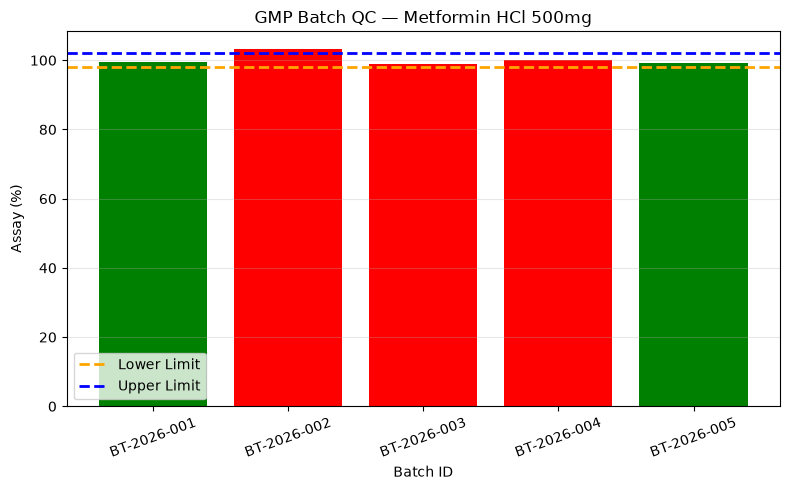

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Batch"      : ["BT-2026-001","BT-2026-002",
                    "BT-2026-003","BT-2026-004",
                    "BT-2026-005"],
    "Assay"      : [99.5, 103.2, 98.8, 100.1, 99.2],
    "Moisture"   : [0.3, 0.4, 0.6, 0.2, 0.3],
    "Dissolution": [88, 85, 82, 78, 91]
}
df = pd.DataFrame(data)

print("=" * 55)
print("  GMP BATCH QC — Metformin HCl 500mg")
print("=" * 55)
print(df.to_string(index=False))

def check_result(df):
    assay_ok = 98.0 <= df["Assay"] <= 102.0
    moist_ok = df["Moisture"] < 0.5
    diss_ok  = df["Dissolution"] > 80
    return "PASS" if assay_ok and moist_ok and diss_ok else "FAIL"
df["Result"] = df.apply(check_result, axis=1)

def fail_reason(df):
    if df["Result"] == "PASS":
        return "-"
    r = []
    if not (98.0 <= df["Assay"] <= 102.0):
        r.append("Assay OOS")
    if df["Moisture"] >= 0.5:
        r.append("Moisture High")
    if df["Dissolution"] <= 80:
        r.append("Dissolution Low")
    return " | ".join(r)
df["Fail_Reason"] = df.apply(fail_reason, axis=1)

print("\n--- Result Summary ---")
print(df["Result"].value_counts().to_string())
print("\n--- Full Report ---")
print(df[["Batch","Assay","Result","Fail_Reason"]]
      .to_string(index=False))

failed = df[df["Result"] == "FAIL"]
print(f"\n⚠ {len(failed)} batch(es) QUARANTINED!")

colors = []

for r in df["Result"]:

    if r == "PASS":
        colors.append("green")

    else:
        colors.append("red")


plt.figure(figsize=(8,5))

plt.bar(
    df["Batch"],
    df["Assay"],
    color=colors
)

plt.axhline(
    y=98,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Lower Limit"
)

plt.axhline(
    y=102,
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Upper Limit"
)

plt.title("GMP Batch QC — Metformin HCl 500mg")

plt.xlabel("Batch ID")

plt.ylabel("Assay (%)")

plt.xticks(rotation=20)

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

